In [9]:
from astropy.io import fits
import os
from astropy.visualization import make_lupton_rgb
from astropy.visualization import PercentileInterval
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS, FITSFixedWarning
from astropy.coordinates import SkyCoord
import shutil
from scipy.ndimage import rotate
import astropy.units as u
import warnings

# These warnings just note that astropy filled in derived WCS
# keywords (DATE-*, OBSGEO-*) from the FITS header -- harmless here.
warnings.filterwarnings("ignore", category=FITSFixedWarning)

In [80]:
ID = 16887
FILTER = "F444W"
line = "PaA"


ROT_ANGLE = -35.74

size = (100, 100)

filters = {
    "blue":  "F200W",
    "green": "F277W",
    "red":   "F444W"
}

BASE_EDR_DATA_DIRECTORY = "/xdisk/egami/aakhtarkavan/edr_products/"

SPEC_PDF_DIRECTORY = (
    "/xdisk/egami/aakhtarkavan/"
    "edr_products/sapphires_edr_spec_pdf"
)

GRISM_OVERVIEW_DIRECTORY = (
    "/home/u7/aakhtarkavan/git_projects/"
    "Galaxy_Kinematics/notebooks/all_sources_grism_imaging"
)

GEKO_RUN_DIRECTORY = (
    "/home/u7/aakhtarkavan/kinematics/"
    "may_runs/batch_of_runs/run2"
)

SOURCE_DIRECTORY = (
    f"/home/u7/aakhtarkavan/git_projects/"
    f"Galaxy_Kinematics/sources/{ID}"
)

os.makedirs(SOURCE_DIRECTORY, exist_ok=True)

In [81]:
spec = fits.getdata(
    f"{BASE_EDR_DATA_DIRECTORY}"
    "sapphires_edr_catalogs/"
    "sapphires_edr_spec_cat.fits"
)

row = spec[spec['ID'] == ID][0]

ra_source = row['RA']
dec_source = row['DEC']

coord = SkyCoord(
    ra=ra_source*u.deg,
    dec=dec_source*u.deg
)

zspec = row['zspec']

print(zspec)

1.1906


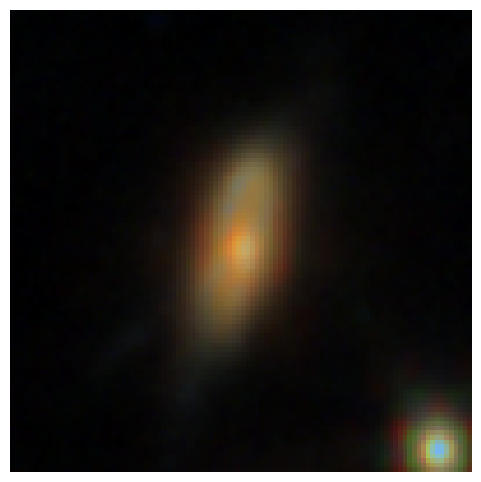

In [82]:
# MAKE CUTOUT FUNCTION
def make_rotated_cutout(filter_name, size, pad_factor=1.6):

    sci_file = (
        f"{BASE_EDR_DATA_DIRECTORY}"
        f"sapphires_edr_nircam_sci/"
        f"4750_{filter_name}_v05_sci.fits"
    )

    hdu = fits.open(sci_file)

    data = hdu['SCI'].data

    wcs = WCS(hdu['SCI'].header)

    # Cut out a larger box than needed so that after rotation
    # there are no zero-padded corners within the final frame.
    pad_size = (
        int(np.ceil(size[0] * pad_factor)),
        int(np.ceil(size[1] * pad_factor)),
    )

    cutout = Cutout2D(
        data,
        position=coord,
        size=pad_size,
        wcs=wcs
    )

    rot = rotate(
        cutout.data,
        angle=ROT_ANGLE,
        reshape=False,
        order=3,
        cval=0.0
    )

    rot = np.nan_to_num(rot)

    # Crop back down to the requested size from the center, now
    # that the rotated edges are clean.
    cy, cx = rot.shape[0] // 2, rot.shape[1] // 2
    half_h, half_w = size[0] // 2, size[1] // 2

    rot = rot[
        cy - half_h: cy + half_h,
        cx - half_w: cx + half_w
    ]

    return rot


# CUTOUTS
blue  = make_rotated_cutout(filters["blue"], size)
green = make_rotated_cutout(filters["green"], size)
red   = make_rotated_cutout(filters["red"], size)


# COLOR COMBINATION (asinh stretch, Lupton et al. 2004)
# This is the same scheme used for most published JWST/HST color
# images: a single nonlinear (asinh) stretch is applied to all
# three channels together so that color ratios are preserved from
# faint outskirts to bright cores, instead of each channel being
# clipped independently (which washes bright regions out to white).
def channel_minimum(img, percentile=1.0):
    return np.nanpercentile(img, percentile)

minimum = [
    channel_minimum(red),
    channel_minimum(green),
    channel_minimum(blue),
]

# stretch sets the linear scale before the asinh nonlinearity --
# smaller values boost faint flux more. Q sets how smoothly the
# bright end rolls off instead of clipping to white.
rgb_cube = make_lupton_rgb(
    red, green, blue,
    minimum=minimum,
    stretch=0.4,
    Q=8
)


# DISPLAY IT
plt.figure(figsize=(6,6))

plt.imshow(
    rgb_cube,
    origin='lower'
)

plt.axis('off')


# SAVE AS PNG
plt.savefig(
    f"{SOURCE_DIRECTORY}/{ID}_rgb_rot.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)

In [83]:
r_pdf = (
    f"{SPEC_PDF_DIRECTORY}/"
    f"spec_2d_M0416_{FILTER}_ID{ID}_R.pdf"
)

c_pdf = (
    f"{SPEC_PDF_DIRECTORY}/"
    f"spec_2d_M0416_{FILTER}_ID{ID}_C.pdf"
)

shutil.copy(r_pdf, SOURCE_DIRECTORY)
shutil.copy(c_pdf, SOURCE_DIRECTORY)

grism_file = (
    f"{GRISM_OVERVIEW_DIRECTORY}/"
    f"{ID}_{FILTER}_{line}_grism_overview.png"
)

shutil.copy(grism_file, SOURCE_DIRECTORY)

'/home/u7/aakhtarkavan/git_projects/Galaxy_Kinematics/sources/21636/21636_F444W_PaA_grism_overview.png'

In [84]:
geko_summary = (
    f"{GEKO_RUN_DIRECTORY}/"
    f"{ID}_summary.png"
)

shutil.copy(geko_summary, SOURCE_DIRECTORY)

'/home/u7/aakhtarkavan/git_projects/Galaxy_Kinematics/sources/21636/21636_summary.png'

In [85]:
geko_block = (
    f'<img src="{ID}_summary.png" class="img-fluid rounded shadow">'
    if os.path.exists(f"{SOURCE_DIRECTORY}/{ID}_summary.png")
    else "GEKO results coming soon"
)

dingo_block = (
    '<img src="dingo_fit.png" class="img-fluid rounded shadow">'
    if os.path.exists(f"{SOURCE_DIRECTORY}/dingo_fit.png")
    else "DINGO results coming soon"
)

html = f"""
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <title>Source {ID}</title>

    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">

</head>

<body class="bg-dark text-light">

<div class="container py-5">

    <!-- BACK BUTTON -->

    <a href="../../index.html"
       class="btn btn-secondary mb-4">
        ← Back
    </a>

    <!-- TOP ROW -->

    <div class="row align-items-start mb-5">

        <!-- LEFT SIDE -->

        <div class="col-md-8">

            <h1 class="mb-1">
                Source {ID}
            </h1>

            <p class="text-secondary fs-5 mb-2">
                z = {zspec:.3f}
            </p>
            
            <p class="mb-1">
                Filter: {FILTER}
            </p>
            
            <p class="mb-0">
                Line: {line}
            </p>

        </div>

        <!-- RIGHT SIDE -->

        <div class="col-md-4 text-end">

            <img src="{ID}_rgb_rot.png"
                 class="img-fluid rounded shadow"
                 style="max-height: 250px;">

        </div>

    </div>

    <!-- OBSERVATIONS -->

    <h2 class="mb-4">
        Observations
    </h2>

    <div class="mb-5 text-center">

        <img src="{ID}_{FILTER}_{line}_grism_overview.png"
             class="img-fluid rounded shadow">

    </div>

    <!-- SPECTRA -->

    <h2 class="mb-4">
        Spectra
    </h2>

    <div class="row g-4 mb-5">

        <!-- R SPECTRUM -->

        <div class="col-md-6">

            <h5 class="text-center mb-3">
                R Spectrum
            </h5>

            <iframe 
                src="spec_2d_M0416_{FILTER}_ID{ID}_R.pdf"
                width="100%"
                height="400px"
                class="rounded bg-white">
            </iframe>

        </div>

        <!-- C SPECTRUM -->

        <div class="col-md-6">

            <h5 class="text-center mb-3">
                C Spectrum
            </h5>

            <iframe 
                src="spec_2d_M0416_{FILTER}_ID{ID}_C.pdf"
                width="100%"
                height="400px"
                class="rounded bg-white">
            </iframe>

        </div>

    </div>

    <!-- GEKO -->

    <h2 class="mb-4">
        GEKO Results
    </h2>

    <div class="bg-secondary rounded p-5 mb-5 text-center">

        {geko_block}

    </div>

    <!-- DINGO -->

    <h2 class="mb-4">
        DINGO Results
    </h2>

    <div class="bg-secondary rounded p-5 text-center">

        {dingo_block}

    </div>

</div>

</body>

</html>
"""

with open(f"{SOURCE_DIRECTORY}/index.html", "w") as f:
    f.write(html)

In [86]:
card = f"""
        <div class="col-md-4">

            <a href="sources/{ID}/index.html"
               class="text-decoration-none text-light">

                <div class="card bg-secondary border-0 shadow h-100">

                    <img src="sources/{ID}/{ID}_rgb_rot.png"
                         class="card-img-top">

                    <div class="card-body">

                        <h4 class="card-title">
                            Source {ID}
                        </h4>

                        <p class="mb-1">
                            z = {zspec:.3f}
                        </p>

                        <p class="mb-1">
                            {FILTER} · {line}
                        </p>

                        <p class="mb-0">
                            GEKO ✓ &nbsp;&nbsp; DINGO ✓
                        </p>

                    </div>

                </div>

            </a>

        </div>
"""

INDEX_PATH = "../index.html"

with open(INDEX_PATH, "r") as f:

    content = f.read()

if f"Source {ID}" not in content:

    content = content.replace(
        "<!-- SOURCE CARDS -->",
        f"<!-- SOURCE CARDS -->\n\n{card}"
    )

    with open(INDEX_PATH, "w") as f:

        f.write(content)

    print(f"Added Source {ID} to homepage.")

else:

    print(f"Source {ID} already exists in homepage.")

Source 21636 already exists in homepage.
